# Задание
• На основе датасета, который был использован вами для промежуточной аттестации (или другого):

• Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных

• Постройте точечные диаграммы (scatterplots) для таргета и каждой фичи, опишите форму взаимосвязи между переменными

• Разделите датасет на обучающую и тестовую выборки

• Сделайте масштабирование объясняющих переменных

• Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающейвыборке

• Сделайте предсказания целевой переменной для тестовой выборки

• Рассчитайте метрики качества

• Выберите спецификацию модели с наилучшим качеством

• Сделайте выводы относительно полученной модели и ее качества

• Разместите блокнот в GitHub и прикрепите ссылку на блокнот в удаленном репозитории


# Подготовка


## Данные

Данные были сформированы из MSSQL Server базы компании и выгружены в Excel для дальнейшей обработки. В качестве источника представлены два набора данных:
* empl_1.xlsx - список сотрудников по месячно, (date - месяц и год, qnt - количество сотрудников, имеющих доступ к компьютерам, qnt_total - общее количество сотрудников)
* data_1.xlsx - список покупок (я удалил конкретные наименования товаров, оставил только категории( date - месяц и год, category - категория, qnt - количество)

## Описание задачи

В качестве задачи я решил взять предсказание затрат на Мониторы в следующем месяце (взял только одну категорию товаров, для примера).


## Импорт пакетов

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations

sns.set_theme()

## Загрузка данных

In [53]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (129, 3)
Покупки:  (4728, 4)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


In [54]:
dataRaw.groupby("category").agg(recCount = ("date", "count")).sort_values("recCount", ascending = False)

,recCount
category,
Запчасти для принтера,982
Картридж,801
Прочее,603
Тонер/Чернила,330
Кабель/Адаптер,303
Жесткий диск,222
Мышь,172
Запчасти для компьютера,158
Компьютер/Ноутбук,143


## Подготавливаем данные

In [55]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date  total_qty  qty  delta  year  month  quarter
0   2016-01-01        842  484    0.0  2016      1        1
1   2016-02-01        840  483   -1.0  2016      2        1
2   2016-03-01        841  487    4.0  2016      3        1
3   2016-04-01        841  489    2.0  2016      4        2
4   2016-05-01        838  489    0.0  2016      5        2
..         ...        ...  ...    ...   ...    ...      ...
124 2026-05-01        997  577    5.0  2026      5        2
125 2026-06-01        997  576   -1.0  2026      6        2
126 2026-07-01        998  578    2.0  2026      7        3
127 2026-08-01        996  577   -1.0  2026      8        3
128 2026-09-01        996  577    0.0  2026      9        3

[129 rows x 7 columns]


In [56]:
## Покупки
dataMonitor = ((
    dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Запчасти для принтера"] # Самая большая выборка
    #dataRaw[dataRaw["category"] == "Картридж"]
    #dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    # заполняем пропуски методом средней интерполяции
    .interpolate(method='linear')
    .assign(
        is_crysis = lambda x: x["year"] >= 2022,
        is_winter = lambda x: x["month"].isin([1, 2, 12]),
        is_spring = lambda x: x["month"].isin([3, 4, 5]),
        is_summer = lambda x: x["month"].isin([6, 7, 8]),
        # количество за прошлый месяц
        qty_lag1 = lambda x: x["qty"].shift(1),
        # сумма за прошлый месяц
        sum_lag1 = lambda x: x["sum"].shift(1),
        # сумма за прошлый месяц
        sum_lag2 = lambda x: x["sum"].shift(2),
        # среднее количество за прошлый месяц
        sum_avg3 = lambda x: x["sum"].rolling(window=3, min_periods=1).mean(),
        # среднее количество за прошлый год
        sum_avg12 = lambda x: x["sum"].rolling(window=12, min_periods=1).mean(),
        # сумма за прошлый месяц
        data_qty_lag1 = lambda x: x["data_qty"].shift(1),
        # сумма за прошлый месяц
        data_qty_lag2 = lambda x: x["data_qty"].shift(2),
        # количество за прошлый месяц
        data_qty_avg3 = lambda x: x["data_qty"].rolling(window=3, min_periods=1).mean(),
        # среднее количество за прошлый год
        data_qty_avg12 = lambda x: x["data_qty"].rolling(window=12, min_periods=1).mean(),
    )
    # заполняем пропуски последующие
    .ffill()
    # заполняем пропуски предыдущие
    .bfill()
    # заполняем пустоты
    .fillna(0)
).sort_values("date").reset_index(drop=True))
#Суммарное значение
dataMonitor["data_qty_cumsum"] = dataMonitor["data_qty"].cumsum()
# Поиск количества старых мониторов
dates  = pd.to_datetime(dataMonitor["date"])
cumsum = pd.Series(dataMonitor["data_qty"].cumsum().values, index=dates)
cutoff = dates - pd.DateOffset(years=5)
dataMonitor["data_qty_old_by_years"] = (
    cumsum.reindex(cutoff, method="ffill")
          .fillna(0)
          .to_numpy()
)

print(dataMonitor.tail(5))

          date  data_qty        sum  total_qty  qty  delta  year  month  \
124 2026-05-01       6.0   67738.51        997  577    5.0  2026      5   
125 2026-06-01       6.0   74852.46        997  576   -1.0  2026      6   
126 2026-07-01      12.0  141147.60        998  578    2.0  2026      7   
127 2026-08-01      12.0  141147.60        996  577   -1.0  2026      8   
128 2026-09-01      12.0  141147.60        996  577    0.0  2026      9   

     quarter  is_crysis  ...   sum_lag1   sum_lag2       sum_avg3  \
124        2       True  ...   59972.15   63770.50   63827.053333   
125        2       True  ...   67738.51   59972.15   67521.040000   
126        3       True  ...   74852.46   67738.51   94579.523333   
127        3       True  ...  141147.60   74852.46  119049.220000   
128        3       True  ...  141147.60  141147.60  141147.600000   

         sum_avg12  data_qty_lag1  data_qty_lag2  data_qty_avg3  \
124  109348.876250            6.0            5.0       5.666667   


In [57]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test):
    return model.predict(X_test)

def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

def add_metrics(df, colums, y_true, y_pred):
    '''
    Функция добавляет в DataFrame статистику
    '''
    df.loc[len(df)] = {
        "Param": colums,
        "MSE" : mean_squared_error(y_true, y_pred),
        "RMSE" : root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE" : mean_absolute_percentage_error(y_true, y_pred),
        "R2" : r2_score(y_true, y_pred)
    }

def draw_scatteplot(df, x, y, xlab, ylab, y_pred = None):
    data = df.copy()
    plt.figure(figsize = (15,5))
    sns.scatterplot(x = x, y = y, data = data)
    if y_pred is not None:
        data["y_pred"] = y_pred
        sns.lineplot(x = x, y = "y_pred", data = data, c = 'forestgreen')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

# Домашнее задание

## 1. Подготовка данных

Было:  (129, 24)
Стало:  (122, 11)


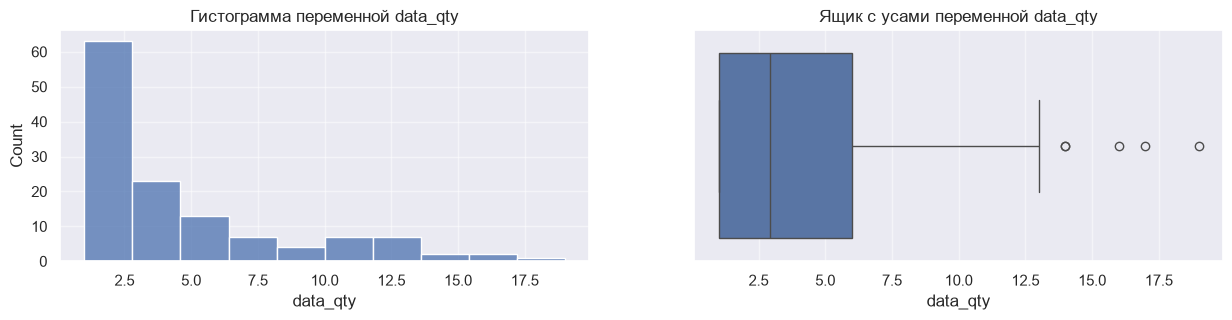

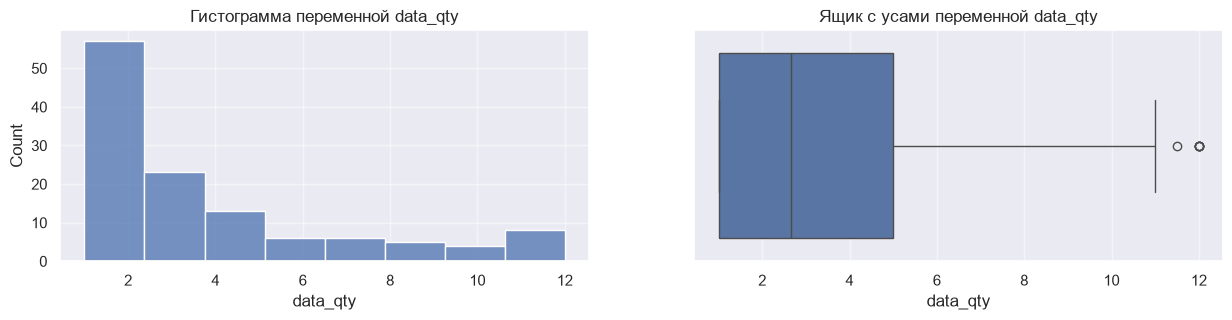

In [58]:
# Указываем целевую переменную
# Максимальное значение VIF, которое не должно превышать
vif_limit = 7
# Количество мониторов
target_column = 'data_qty'
lag_column = 'data_qty_lag1'
lag2_column = 'data_qty_lag2'
avg_column = 'data_qty_avg3'
# Сумма по мониторам
# target_column = 'sum'
# lag_column = 'sum_lag1'
# lag2_column = 'sum_lag2'
# avg_column = 'sum_avg3'

# Убираем выбросы по правилу +/- 2 стандартных отклонения, z-score'
numeric_cols = [target_column, lag_column, lag2_column, avg_column, 'is_crysis', 'is_winter', 'is_spring', 'is_summer',  'qty_lag1',
                'data_qty_cumsum', 'data_qty_old_by_years']
df = dataMonitor[numeric_cols]
#df = df[dataMonitor["is_crysis"] == True]
# Очищаем от выбросов
df = df[np.abs((df[target_column]-df[target_column].mean())/df[target_column].std())<=2]
print("Было: ", dataMonitor.shape)
print("Стало: ", df.shape)
visualize_distribution(dataMonitor[numeric_cols], variable = target_column)
visualize_distribution(df, variable = target_column)

In [59]:
df.head()

,data_qty,data_qty_lag1,data_qty_lag2,data_qty_avg3,is_crysis,is_winter,is_spring,is_summer,qty_lag1,data_qty_cumsum,data_qty_old_by_years
0,1.0,1.0,1.0,1.0,False,True,False,False,484.0,1.0,0.0
1,1.0,1.0,1.0,1.0,False,True,False,False,484.0,2.0,0.0
2,1.0,1.0,1.0,1.0,False,False,True,False,483.0,3.0,0.0
3,1.0,1.0,1.0,1.0,False,False,True,False,487.0,4.0,0.0
4,1.0,1.0,1.0,1.0,False,False,True,False,489.0,5.0,0.0


data_qty - Целевая переменная количество мониторов для покупки

## 2. Изучаем связь целевой переменной и предикторов

In [ ]:
fig = plt.figure(figsize = (15, 15))
sns.pairplot(df)
plt.show()

<Figure size 1500x1500 with 0 Axes>

## Variance inflation factor

In [ ]:
# Берем предикты все числовые колонки, кроме целевой
features_col = numeric_cols
if (target_column in features_col):
    features_col.remove(target_column)

found = False

while not found:
    print("\nПробуем с набором ", features_col)
    X = df[features_col]
    y = df[target_column]

    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    vif_data = vif_data.sort_values(by = 'VIF', ascending = False).reset_index(drop = True)

    print(vif_data)

    # делаем исключение мультиколлинеарности для первой записи, если она превышает vif_limit

    if vif_data.loc[0]["VIF"] >= vif_limit:
        print(f"Предикт {vif_data.loc[0]["feature"]} имеет слишком большой VIF = {vif_data.loc[0]["VIF"]}, исключаем его")
        vif_data = vif_data.iloc[1:]

    temp_list = vif_data["feature"].tolist()
    found = features_col == temp_list
    features_col = temp_list

print ("\nИтоговый результат:", features_col)

## Lasso регрессия

In [ ]:
# Попробуем автоматизировать процесс:

# Определим целевую переменную и количественные предикты
results = pd.DataFrame(columns=[
    "Param", "MSE", "RMSE", "MAE", "MAPE", "R2"
])

for r in range(1, len(features_col) + 1):   # от 1 до длины списка, пустой вариант исключён
    for check_columns in combinations(features_col, r):
        # Разобьем на тестовую и обучающую
        X_train, X_test, y_train, y_test = split_train_test(df, np.array(check_columns).tolist(), target_column)

        # Проведем масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = Lasso(alpha = 0.1)
        model.fit(X_train_scaled, y_train)

        y_pred = get_predictions(model, X_test_scaled)
        add_metrics(results, check_columns, y_test, y_pred)

In [ ]:
# Найдем лучшую по минимальной средней ошибке (RMSE)
df_sorted_by_min_rmse = results.sort_values("RMSE", ascending=True)

# Лучшая модель по максимальному R2
df_sorted_by_max_r2 = results.sort_values("R2", ascending=False)

print("Минимальная RMSE:")
print(df_sorted_by_min_rmse.head(3))
print("Максимальная R2:")
print(df_sorted_by_max_r2.head(3))

Проанализировав текущие данные, видно что и при поиске минимальных средних ошибок и при поиске максимальной R2 список колонок одинаковый, я принимаю решение, что оптимальным списков предиктов будет

In [ ]:
best_column_list_lasso = df_sorted_by_max_r2.iloc[0]["Param"]
print("Список колонок: ", best_column_list_lasso)

## Ridge регрессия

In [ ]:
# Попробуем автоматизировать процесс:
from itertools import combinations

# Определим целевую переменную и количественные предикты
results = pd.DataFrame(columns=[
    "Param", "MSE", "RMSE", "MAE", "MAPE", "R2"
])

for r in range(1, len(features_col) + 1):   # от 1 до длины списка, пустой вариант исключён
    for check_columns in combinations(features_col, r):
        # Разобьем на тестовую и обучающую
        X_train, X_test, y_train, y_test = split_train_test(df, np.array(check_columns).tolist(), target_column)

        # Проведем масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = Ridge(alpha = 0.1)
        model.fit(X_train_scaled, y_train)

        y_pred = get_predictions(model, X_test_scaled)
        add_metrics(results, check_columns, y_test, y_pred)

In [ ]:
# Найдем лучшую по минимальной средней ошибке (RMSE)
df_sorted_by_min_rmse = results.sort_values("RMSE", ascending=True)

# Лучшая модель по максимальному R2
df_sorted_by_max_r2 = results.sort_values("R2", ascending=False)

print("Минимальная RMSE:")
print(df_sorted_by_min_rmse.head(3))
print("Максимальная R2:")
print(df_sorted_by_max_r2.head(3))

Проанализировав текущие данные, видно что и при поиске минимальных средних ошибок и при поиске максимальной R2 список колонок одинаковый, я принимаю решение, что оптимальным списков предиктов будет

In [ ]:
best_column_list_ridge = df_sorted_by_max_r2.iloc[0]["Param"]
print("Список колонок: ", best_column_list_ridge)

## Проверка на устойчивость

In [ ]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

stable_lasso = pd.DataFrame(columns=[
    "Param", "MSE", "RMSE", "MAE", "MAPE", "R2"
])

for random_state in range(0, 20, 2):

    X_train, X_test, y_train, y_test = train_test_split(df[np.array(best_column_list_lasso).tolist()], df[target_column], test_size = 0.33, random_state = random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Lasso(alpha = 0.1)
    model.fit(X_train_scaled, y_train)

    y_pred = get_predictions(model, X_test_scaled)

    add_metrics(stable_lasso, random_state, y_test, y_pred)

    df2 = pd.DataFrame(
      index = X_train.columns,
      data = model.coef_[0],
      columns = [random_state]
    )

    coefs_df = pd.concat([coefs_df, df2], axis = 1)

print(stable_lasso)
print(coefs_df.T)

In [ ]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

stable_ridge = pd.DataFrame(columns=[
    "Param", "MSE", "RMSE", "MAE", "MAPE", "R2"
])

for random_state in range(0, 20, 2):

    X_train, X_test, y_train, y_test = train_test_split(df[np.array(best_column_list_ridge).tolist()], df[target_column], test_size = 0.33, random_state = random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Ridge(alpha=0.1)
    model.fit(X_train_scaled, y_train)

    y_pred = get_predictions(model, X_test_scaled)

    add_metrics(stable_ridge, random_state, y_test, y_pred)

    df2 = pd.DataFrame(
      index = X_train.columns,
      data = model.coef_[0],
      columns = [random_state]
    )

    coefs_df = pd.concat([coefs_df, df2], axis = 1)

print(stable_ridge)
print(coefs_df.T)

In [ ]:
# Выводы по модели

print("\nРазброс LASSO R2 (%): {:.3f} - {:.3f} (в среднем {:.3f})"
    .format(
         stable_lasso.loc[stable_lasso["R2"].idxmin()]["R2"] * 100,
         stable_lasso.loc[stable_lasso["R2"].idxmax()]["R2"] * 100,
         stable_lasso["R2"].mean() * 100
    )
)
print("\nРазброс Ridge R2 (%): {:.3f} - {:.3f} (в среднем {:.3f})"
    .format(
        stable_ridge.loc[stable_ridge["R2"].idxmin()]["R2"] * 100,
        stable_ridge.loc[stable_ridge["R2"].idxmax()]["R2"] * 100,
        stable_ridge["R2"].mean() * 100
    )
)